In [1]:
import numpy as np
from compartments import CompartmentPatchArray, SEIRV_patch_stepper

In [2]:
NUMPATCHES = 2
NUMCOMPARTMENTS = 5

# Patches not communicating with each other

Patch 1 has a 0 contact rate while the other has a finite contact rate, then we expect one patch to have no growth in infection. To remove all sources of randomness we plug the weibull scale as 0.

In [3]:
init_state = np.array([[10000, 3, 2, 0, 0], [10000, 3, 2, 0, 0]], dtype = float)
seirv_state = CompartmentPatchArray(
    state= init_state,
    num_compartments=NUMCOMPARTMENTS,
    num_patches=NUMPATCHES,
    iter_num=0
)


In [4]:
vaccinations = np.array((0,0))
VACCINE_EFFICACY = 0
WEIBULL_WANING_SHAPE = 0
WEIBULL_WANING_SCALE = 0
params_stepper = {
        'gamma': 1/5,
        'alpha': 1/5.8,
        'vaccination_14_days_prior': vaccinations,
        'vaccine_efficacy': VACCINE_EFFICACY,
        'waning_weibull_shape': WEIBULL_WANING_SHAPE,
        'waning_weibull_scale': WEIBULL_WANING_SCALE
        }

In [5]:
patchstates = []
STEPS = 100
betas_patches = np.array((0, 1))
network_matrix = np.eye(2)
for i in range(STEPS):
    step = SEIRV_patch_stepper(
        compartment_patch_array=seirv_state,
        network_matrix=network_matrix,
        betas_patches=betas_patches,
        **params_stepper
    )
    patchstates.append(seirv_state.get_copy_of_the_state())
    seirv_state.update_state(seirv_state.state + step)
    seirv_state.incr_iter_num()


In [6]:
patchstates = np.array(patchstates)
patchstates.shape

(100, 2, 5)

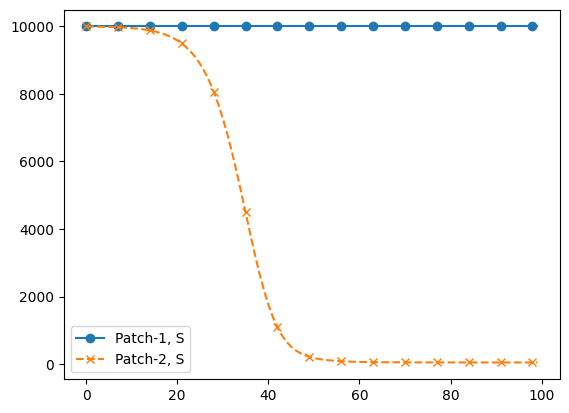

In [7]:
import matplotlib.pyplot as plt

plt.plot(patchstates[:,0, 0], marker = 'o', markevery = 7, label = 'Patch-1, S')
plt.plot(patchstates[:,1, 0], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, S')
plt.legend()

# Patches communicating only with each other

In [8]:
init_state = np.array([[10000, 3, 2, 0, 0], [10000, 3, 2, 0, 0]], dtype = float)
seirv_state = CompartmentPatchArray(
    state= init_state,
    num_compartments=NUMCOMPARTMENTS,
    num_patches=NUMPATCHES,
    iter_num=0
)


In [9]:
vaccinations = np.array((0,0))
VACCINE_EFFICACY = 1
WEIBULL_WANING_SHAPE = 5.7
WEIBULL_WANING_SCALE = 120
params_stepper = {
        'gamma': 1/5,
        'alpha': 1/5.8,
        'vaccination_14_days_prior': vaccinations,
        'vaccine_efficacy': VACCINE_EFFICACY,
        'waning_weibull_shape': WEIBULL_WANING_SHAPE,
        'waning_weibull_scale': WEIBULL_WANING_SCALE
        }

In [10]:
patchstates = []
STEPS = 200
betas_patches = np.array((1, 1))
network_matrix = np.array(((0, 1), (1, 0)))
for i in range(STEPS):
    step = SEIRV_patch_stepper(
        compartment_patch_array=seirv_state,
        network_matrix=network_matrix,
        betas_patches=betas_patches,
        **params_stepper
    )
    # print('-------\n', seirv_state.state, '\n ')
    # print(step)
    patchstates.append(seirv_state.get_copy_of_the_state())
    seirv_state.update_state(seirv_state.state + step)
    seirv_state.incr_iter_num()
patchstates = np.array(patchstates)

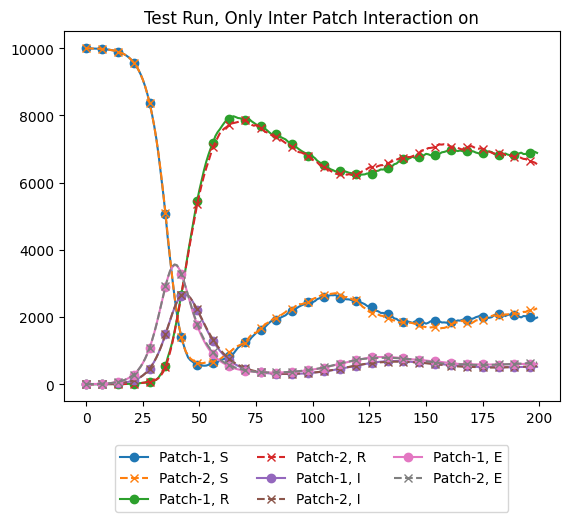

In [11]:
import matplotlib.pyplot as plt
plt.plot(patchstates[:,0, 0], marker = 'o', markevery = 7, label = 'Patch-1, S')
plt.plot(patchstates[:,1, 0], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, S')

plt.plot(patchstates[:,0, 3], marker = 'o', markevery = 7, label = 'Patch-1, R')
plt.plot(patchstates[:,1, 3], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, R')


plt.plot(patchstates[:,0, 2], marker = 'o', markevery = 7, label = 'Patch-1, I')
plt.plot(patchstates[:,1, 2], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, I')



plt.plot(patchstates[:,0, 1], marker = 'o', markevery = 7, label = 'Patch-1, E')
plt.plot(patchstates[:,1, 1], marker = 'x', linestyle = 'dashed', markevery = 7, label = 'Patch-2, E')

plt.title('Test Run, Only Inter Patch Interaction on')

plt.legend(bbox_to_anchor=(0.5, -0.1), loc='upper center', ncol = 3)

## Modelling Karnataka Covid 1st Wave Data

In [12]:
import pandas as pd

In [13]:
weibull_shape = 3.7
weibull_scale = 120
age_stratification = [i*5 for i in range(80//5)]

In [14]:
age_dist_project = pd.read_csv("karnataka-data/age_dist_projected_karnataka.csv")
age_dist_project.head()
total_pop_project = (age_dist_project['Population'][age_dist_project['Age group'] == 'Total']).iloc[0]
age_dist_project['Fraction'] = age_dist_project['Population']/66845
print(total_pop_project)
age_dist_project = age_dist_project.drop(index=17)

66845


In [15]:
casesfile = "karnataka-data/IRDD_allka.csv"
casesframe = pd.read_csv(casesfile)
casesframe = casesframe[casesframe['District']!='Karnataka']
casesframe = casesframe[casesframe['District']!='Others']
districts = casesframe['District'].unique()
len(districts)

30

In [16]:
casesframe

,Date,District,Infected,Recovered,Deceased
0,22-03-2020,Bagalakote,0,0,0
1,23-03-2020,Bagalakote,0,0,0
2,24-03-2020,Bagalakote,0,0,0
3,25-03-2020,Bagalakote,0,0,0
4,26-03-2020,Bagalakote,0,0,0
...,...,...,...,...,...
31285,28-01-2023,Yadgiri,41233,40710,522
31286,29-01-2023,Yadgiri,41233,40710,522
31287,30-01-2023,Yadgiri,41233,40711,522
31288,31-01-2023,Yadgiri,41233,40711,522


<Figure size 640x480 with 0 Axes>

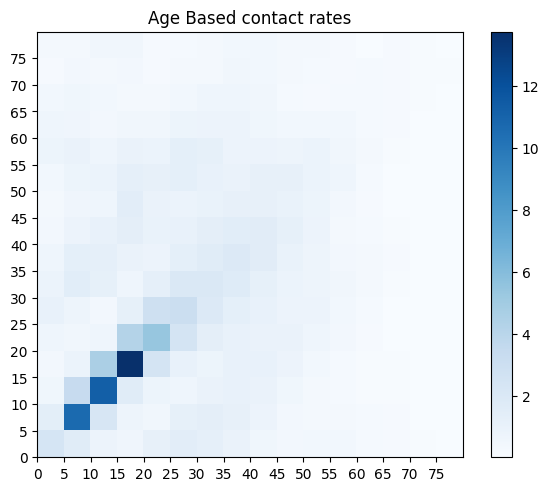

In [17]:
%matplotlib inline
plt.clf()
fig, axs = plt.subplots(1, 1, constrained_layout = True)
age_rate_contact_matrix = np.loadtxt('karnataka-data/ageinteractionmat.csv')
map =axs.imshow(age_rate_contact_matrix, cmap ='Blues', origin='lower')

edge_positions = np.arange(age_rate_contact_matrix.shape[1] ) -0.5
axs.set_xticks(edge_positions)
axs.set_yticks(edge_positions)

axs.set_yticklabels(age_stratification)
axs.set_xticklabels(age_stratification)
axs.set_title('Age Based contact rates')
plt.colorbar(mappable=map, ax=axs)
plt.show()

In [18]:
age_rate_contact_matrix.mean()

np.float64(0.8237482727615939)

### Assuming the mobility matrix to be identity

For identity mobility, the

In [37]:
# numpatches = len(age_stratification) * len(districts)
# print(numpatches)
# numagegroups = len(age_stratification)
# network_matrix_patch = np.zeros((numpatches, numpatches))
# for i in range(len(districts)):
#     network_matrix_patch[i*numagegroups:(i+1)*numagegroups, i*numagegroups:(i+1)*numagegroups] = age_rate_contact_matrix


# currently we define the patch as the 
numpatches = len(districts)
epsilon = 0.01
network_matrix_patch_ka = epsilon
network_matrix_patch_ka += np.eye(numpatches) - epsilon*np.eye(numpatches)   
network_matrix_patch_ka = network_matrix_patch_ka* 10 # age_rate_contact_matrix.mean()

In [38]:
# !pip install openpyxl
popdatafile = "karnataka-data/finalPopulationData.xlsx"
population_district_2011 = pd.read_excel(popdatafile)
initial_population = population_district_2011['Cowin Population']
initial_population = np.array(initial_population)

In [39]:
population_district_2011
b = population_district_2011['district']
b = sorted(b)

In [40]:
betas_patch_dataframe = pd.read_csv("karnataka-data/betas_paper.csv")
# betas_patch_dataframe.head(10)

In [41]:
# Bengaluru-Rural
betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == "Bagalkot", "Unit"] = "Bagalkote"
betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == "Rest of Bengaluru-Urban", "Unit"] = "Bengaluru Urban"
betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == "Bengaluru-Rural", "Unit"] = "Bengaluru Rural"
betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == "Chamarajanagar", "Unit"] = "Chamarajanagara"
betas_patch_dataframe.head()



,Unit,T1,T2,T3,T4,T5
0,BBMP-Bommanahalli,0.018,0.025,0.074,0.040,0.047
1,BBMP-Dasarahalli,0.016,0.022,0.056,0.038,0.042
2,BBMP-East,0.041,0.022,0.060,0.043,0.047
3,BBMP-Mahadevpura,0.013,0.021,0.062,0.042,0.043
4,BBMP-RR-Nagar,0.019,0.023,0.092,0.043,0.062


In [42]:
a = betas_patch_dataframe['Unit'].unique()[8:]
a = sorted(a)
b = sorted(b)
for i in range(len(a)):
    # print(i, a[i], b[i])
    betas_patch_dataframe.loc[betas_patch_dataframe["Unit"] == a[i], "Unit"] = b[i]
    # print(betas_patch_dataframe.loc[i+8]["Unit"], i)

In [43]:
betas_patch_dataframe = betas_patch_dataframe.iloc[8:]

In [44]:
betas_patch_dataframe =betas_patch_dataframe.rename(columns={'Unit':'district'})

In [45]:
len(betas_patch_dataframe['district'].unique())

30

In [46]:
combined_data = population_district_2011.merge(betas_patch_dataframe, how='inner', on = 'district')
cmbsort = sorted(combined_data['district'].unique())
# for i in range(len(cmbsort)):
#     print(a[i], cmbsort[i])
len(combined_data['district'].unique())

30

In [47]:
combined_data.head()

,district,data,2011_pop,Factor,Cowin Population,T1,T2,T3,T4,T5
0,Kodagu,3.966888e+05,392248,1.011322,400000,0.021,0.024,0.045,0.025,0.078
1,Bagalakote,1.353783e+06,1194478,1.133368,1362000,0.006,0.017,0.018,0.008,0.043
2,Ballari,1.964513e+06,1555994,1.262545,2068000,0.010,0.025,0.057,0.015,0.056
3,Belagavi,3.523548e+06,3145147,1.120313,3566000,0.013,0.025,0.032,0.012,0.046
4,Bengaluru Rural,8.044783e+05,699465,1.150134,819000,0.019,0.025,0.061,0.046,0.049


In [48]:
population = np.array(combined_data['Cowin Population'])
population.shape

(30,)

In [67]:
timescols = {
    20:'T1',
    140:'T2',
    165:'T3',
    188:'T4',
}
terminus_time = 'T5'

timeslist = sorted([ keys for keys in timescols.keys()])
T = sum(timeslist)
T = 300

initial_population = np.array(combined_data['Cowin Population'])
print(numpatches, initial_population.shape)


initial_states = np.zeros((numpatches, 5))
ratio = 10000/initial_population.sum()
initial_states[:,0] = initial_population*(1-ratio)
initial_states[:,1] = initial_population*ratio*0.3
initial_states[:,2] = initial_population*ratio*0.7


total_population = initial_population.sum()
betas_patches = np.array(combined_data['T1'])
vaccination_arr = np.zeros(numpatches)

patchstates = CompartmentPatchArray(
    state= initial_states,
    num_patches=numpatches,
    num_compartments=5,
    iter_num=0
    )
ALPHA = 1/5.8
GAMMA = 1/5

states = []
counter = 0
for i in range(T):

    if counter<len(timeslist):
        timescale = timescols[timeslist[counter]]
    else:
        timescale = terminus_time
    betas_patches = np.array(combined_data[timescale])
    print(betas_patches[0])
    step_state = SEIRV_patch_stepper(
        compartment_patch_array=patchstates,
        vaccination_14_days_prior= np.zeros((numpatches,)),
        vaccine_efficacy=0,
        betas_patches=betas_patches,
        alpha=ALPHA,
        gamma=GAMMA,
        network_matrix=network_matrix_patch_ka,
        waning_weibull_scale=120,
        waning_weibull_shape=3.7
    )
    # print(step_state[0,:])
    # print(patchstates.state[0,:])
    if counter < len(timeslist):
        if i> timeslist[counter]:
            counter+=1
    
    assert np.isclose(initial_population.sum(), patchstates.state.sum())
    states.append(patchstates.get_copy_of_the_state())
    patchstates.update_state(patchstates.state + step_state)

30 (30,)
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.021
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.024
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0.045
0

13869.162133432808 43399027.12785312


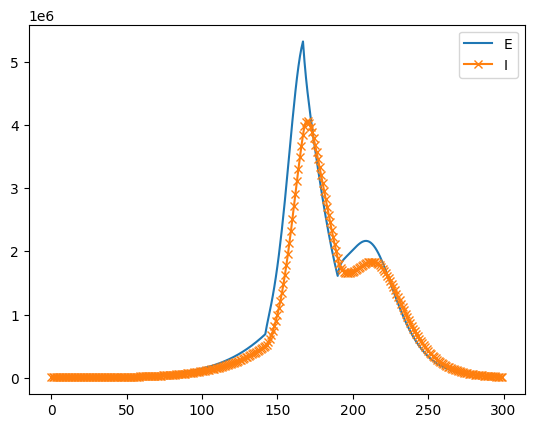

In [69]:
states = np.array(states)
assert states.shape == (T, numpatches, 5)
total_ka = states.sum(axis = 1)
# plt.plot(total_ka[:,0])
# plt.plot(total_ka[:,0], label = 'S')
plt.plot(total_ka[:,1], label = 'E')
plt.plot(total_ka[:,2], label = 'I', marker = 'x', markevery = 1)
# plt.plot(total_ka[:,3], label = 'R')
# plt.plot(total_ka[:,4], label = 'V')
plt.legend()
print(total_ka[-1,2],total_ka[-1,3],)

In [ ]:
185337.5491612476 340968.3249862892

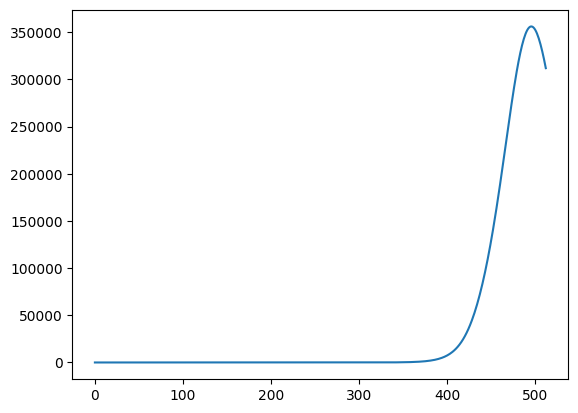

In [33]:
plt.plot(states[:,5, 1])

In [34]:
b = ['Kodagu', 'Bagalakote', 'Ballari', 'Belagavi', 'Bengaluru Rural',
       'Bengaluru Urban', 'Bidar', 'Chamarajanagara', 'Chikkaballapura',
       'Chikkamagaluru', 'Chitradurga', 'Dakshina Kannada', 'Davanagere',
       'Dharwad', 'Gadag', 'Hassan', 'Haveri', 'Kalaburagi', 'Kolar',
       'Koppal', 'Mandya', 'Mysuru', 'Raichur', 'Ramanagara',
       'Shivamogga', 'Tumakuru', 'Udupi', 'Uttara Kannada', 'Vijayapura',
       'Yadgiri']



len(a)

30

In [35]:

len(b)

30

In [36]:
sorted(b)

['Bagalakote',
 'Ballari',
 'Belagavi',
 'Bengaluru Rural',
 'Bengaluru Urban',
 'Bidar',
 'Chamarajanagara',
 'Chikkaballapura',
 'Chikkamagaluru',
 'Chitradurga',
 'Dakshina Kannada',
 'Davanagere',
 'Dharwad',
 'Gadag',
 'Hassan',
 'Haveri',
 'Kalaburagi',
 'Kodagu',
 'Kolar',
 'Koppal',
 'Mandya',
 'Mysuru',
 'Raichur',
 'Ramanagara',
 'Shivamogga',
 'Tumakuru',
 'Udupi',
 'Uttara Kannada',
 'Vijayapura',
 'Yadgiri']